# Modeling: disengagement prediction

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/employee_engagement.csv')
features = ['recognition_events_received','recognition_events_given','monthly_recognition_frequency','avg_reward_value','tenure_months','absenteeism_days','satisfaction_survey']
X, y = df[features].fillna(0), df['is_disengaged']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}, Disengagement: {y.mean():.1%}')

Train: (6400, 7), Test: (1600, 7), Disengagement: 3.3%


In [2]:
models = {'Logistic Regression': LogisticRegression(max_iter=1000), 'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42), 'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)}
for name, m in models.items():
    sc = cross_val_score(m, X_train, y_train, cv=5, scoring='roc_auc')
    print(f'{name}: AUC = {sc.mean():.3f} (+/- {sc.std():.3f})')

Logistic Regression: AUC = 0.969 (+/- 0.010)


Random Forest: AUC = 0.957 (+/- 0.022)


Gradient Boosting: AUC = 0.970 (+/- 0.011)


In [3]:
best = GradientBoostingClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
y_pred = best.predict(X_test)
y_prob = best.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred, target_names=['Engaged','Disengaged']))
print(f'AUC: {roc_auc_score(y_test, y_prob):.3f}')

              precision    recall  f1-score   support

     Engaged       0.98      0.99      0.99      1548
  Disengaged       0.71      0.52      0.60        52

    accuracy                           0.98      1600
   macro avg       0.85      0.76      0.79      1600
weighted avg       0.98      0.98      0.98      1600

AUC: 0.966


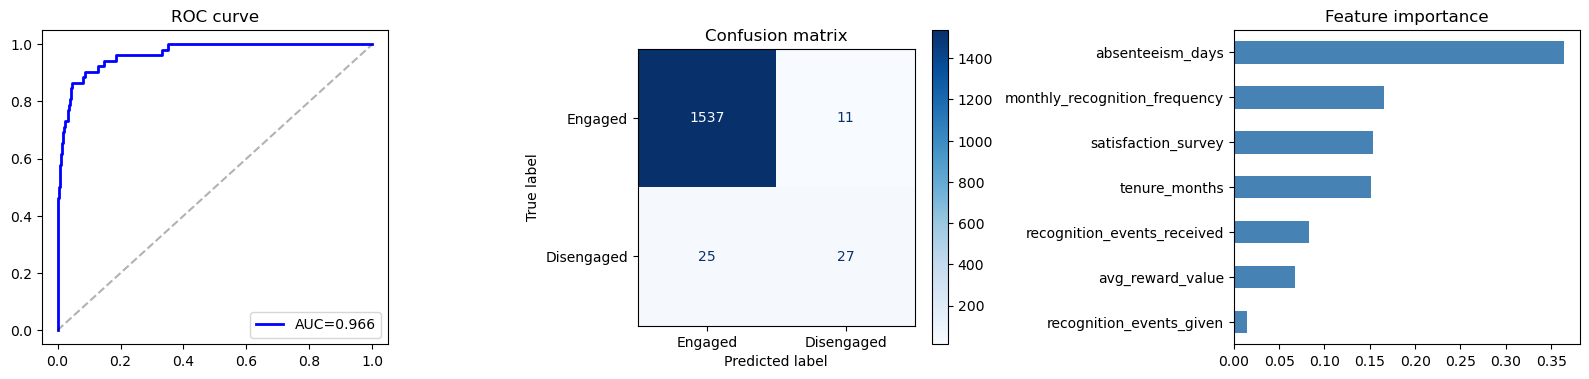

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'AUC={roc_auc_score(y_test, y_prob):.3f}')
axes[0].plot([0,1],[0,1],'k--',alpha=.3)
axes[0].set_title('ROC curve')
axes[0].legend()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1], cmap='Blues', display_labels=['Engaged','Disengaged'])
axes[1].set_title('Confusion matrix')
imp = pd.Series(best.feature_importances_, index=features).sort_values()
imp.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Feature importance')
plt.tight_layout()
plt.show()